In [1]:
import h5py

grp = h5py.File("/vepfs-C/vepfs_public/daijc/lncRNA/results/grads/modisco_ordered_all_win25600_n50000.h5", "r")

all_index = []
for contribution_dir in ['pos', 'neg']:
    patterns_category = f'{contribution_dir}_patterns'
    if patterns_category not in grp:
        continue

    for (pattern_name, datasets) in grp[patterns_category].items():
        all_index.append(
            datasets['seqlets']['example_idx'][:]
        )


In [5]:
all_set = []
for i in all_index:
    all_set += list(set(list(i)))
all_set = set(all_set)

In [6]:
len(all_set)

1560

In [7]:
max(all_set)

np.int64(1562)

In [8]:
i

array([ 831,  501, 1218, ...,  592, 1496,  717], shape=(1088,))

In [1]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib import pyplot as plt

def plot_attention_panel(mat, filename=None, *, cmap="Blues", vmin=0.0001,
                         vmax=0.005, colorbar=True, dpi=600, figsize=(10, 10),
                         variant_id="", show_titles=True, show_xlabel=True,
                         show_xticks=True, show_yticks=False,
                         positions='TOKEN', token_resolution=128, show=True):
    """Plot traditional rectangular attention heatmap (non-triangular style).

    Args:
        mat: Attention matrix to plot.
        filename: Output filename. If None and show=True, displays plot.
        cmap: Colormap name. Defaults to "Blues".
        vmin: Minimum value for color scale. Defaults to 0.0001.
        vmax: Maximum value for color scale. Defaults to 0.005.
        colorbar: Whether to show colorbar. Defaults to True.
        dpi: Figure DPI. Defaults to 600.
        figsize: Figure size tuple. Defaults to (10, 10).
        variant_id: Title for the plot. Defaults to "".
        show_titles: Whether to show title. Defaults to True.
        show_xlabel: Whether to show x-axis label. Defaults to True.
        show_xticks: Whether to show x-axis ticks. Defaults to True.
        show_yticks: Whether to show y-axis ticks. Defaults to False.
        positions: 'TOKEN' or 'BP' for position units. Defaults to 'TOKEN'.
        token_resolution: Base pairs per token. Defaults to 128.
        show: Whether to display plot. Defaults to True.

    Returns:
        matplotlib.figure.Figure: The created figure object.
    """
    # Set up normalization
    vcenter = (vmin + vmax) / 2
    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    im = ax.imshow(mat, cmap=cmap, norm=norm, origin='lower', aspect='auto')

    # Format axes
    use_bp_display = positions.upper() == 'BP'

    ax.tick_params(width=LINE_WIDTH, length=3, labelsize=7)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_linewidth(LINE_WIDTH)
    ax.spines["left"].set_linewidth(LINE_WIDTH)

    if show_xticks and mat.size > 0:
        n_tokens = mat.shape[0]
        tick_positions = [0, n_tokens - 1]
        if use_bp_display:
            max_bp = (n_tokens - 1) * token_resolution
            tick_labels = ['0', str(max_bp)]
        else:
            tick_labels = ['0', str(n_tokens - 1)]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
    else:
        ax.set_xticks([])

    if show_yticks and mat.size > 0:
        n_tokens = mat.shape[0]
        tick_positions = [0, n_tokens - 1]
        if use_bp_display:
            max_bp = (n_tokens - 1) * token_resolution
            tick_labels = ['0', str(max_bp)]
        else:
            tick_labels = ['0', str(n_tokens - 1)]
        ax.set_yticks(tick_positions)
        ax.set_yticklabels(tick_labels)
    else:
        ax.set_yticks([])

    if use_bp_display:
        xlabel_text = "Position (base pairs)"
        ylabel_text = "Position (base pairs)"
    else:
        xlabel_text = "Token position"
        ylabel_text = "Token position"
    if show_xlabel:
        ax.set_xlabel(xlabel_text, fontsize=8)
        ax.set_ylabel(ylabel_text, fontsize=8)

    if show_titles and variant_id:
        ax.set_title(variant_id, fontsize=9, pad=10)

    ax.set_facecolor("white")

    # Add colorbar
    if colorbar:
        cb = plt.colorbar(im, ax=ax, shrink=0.8, aspect=20)
        cb.ax.tick_params(width=LINE_WIDTH*0.8, length=3, labelsize=7, direction="in")
        cb.outline.set_linewidth(LINE_WIDTH*0.8)

    if filename:
        dirname = os.path.dirname(filename)
        if dirname:
            os.makedirs(dirname, exist_ok=True)
        plt.savefig(
            filename, dpi=600, bbox_inches="tight", facecolor='white'
        )
        print(f"✅ Saved attention plot: {filename}")
        if not show:
            plt.close(fig)
    elif show:
        plt.show()
    else:
        plt.close(fig)

    return fig

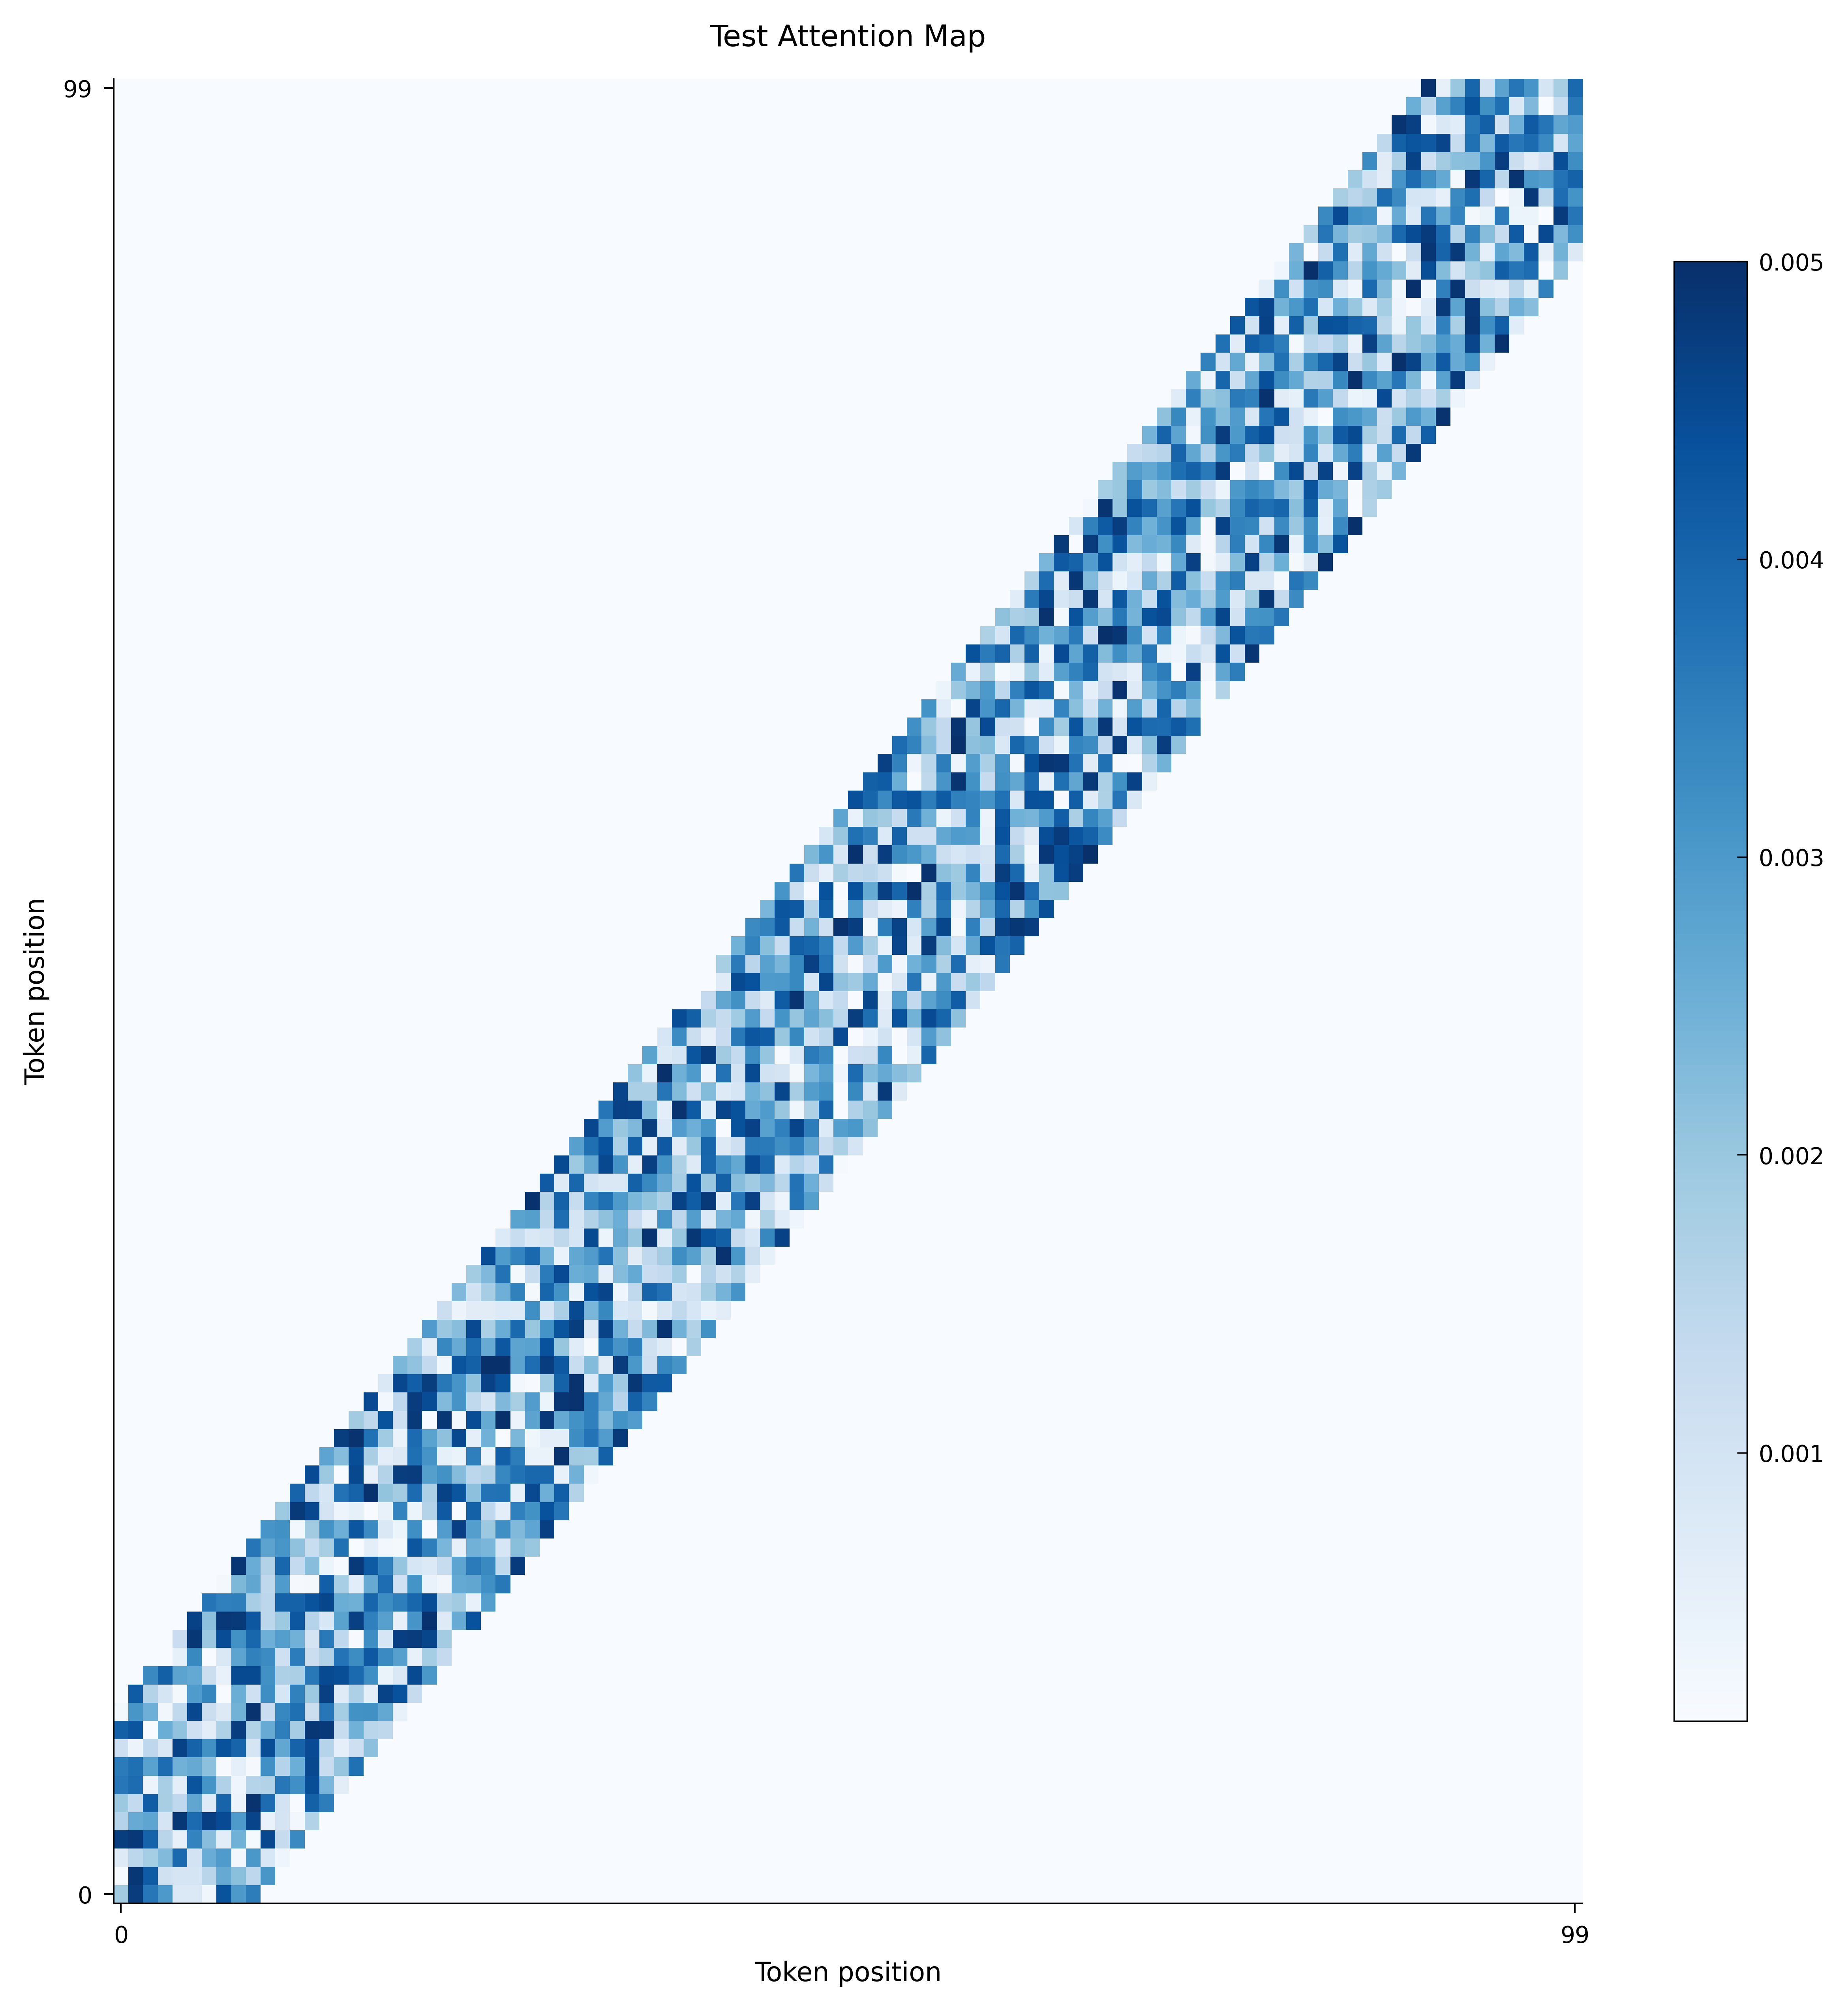

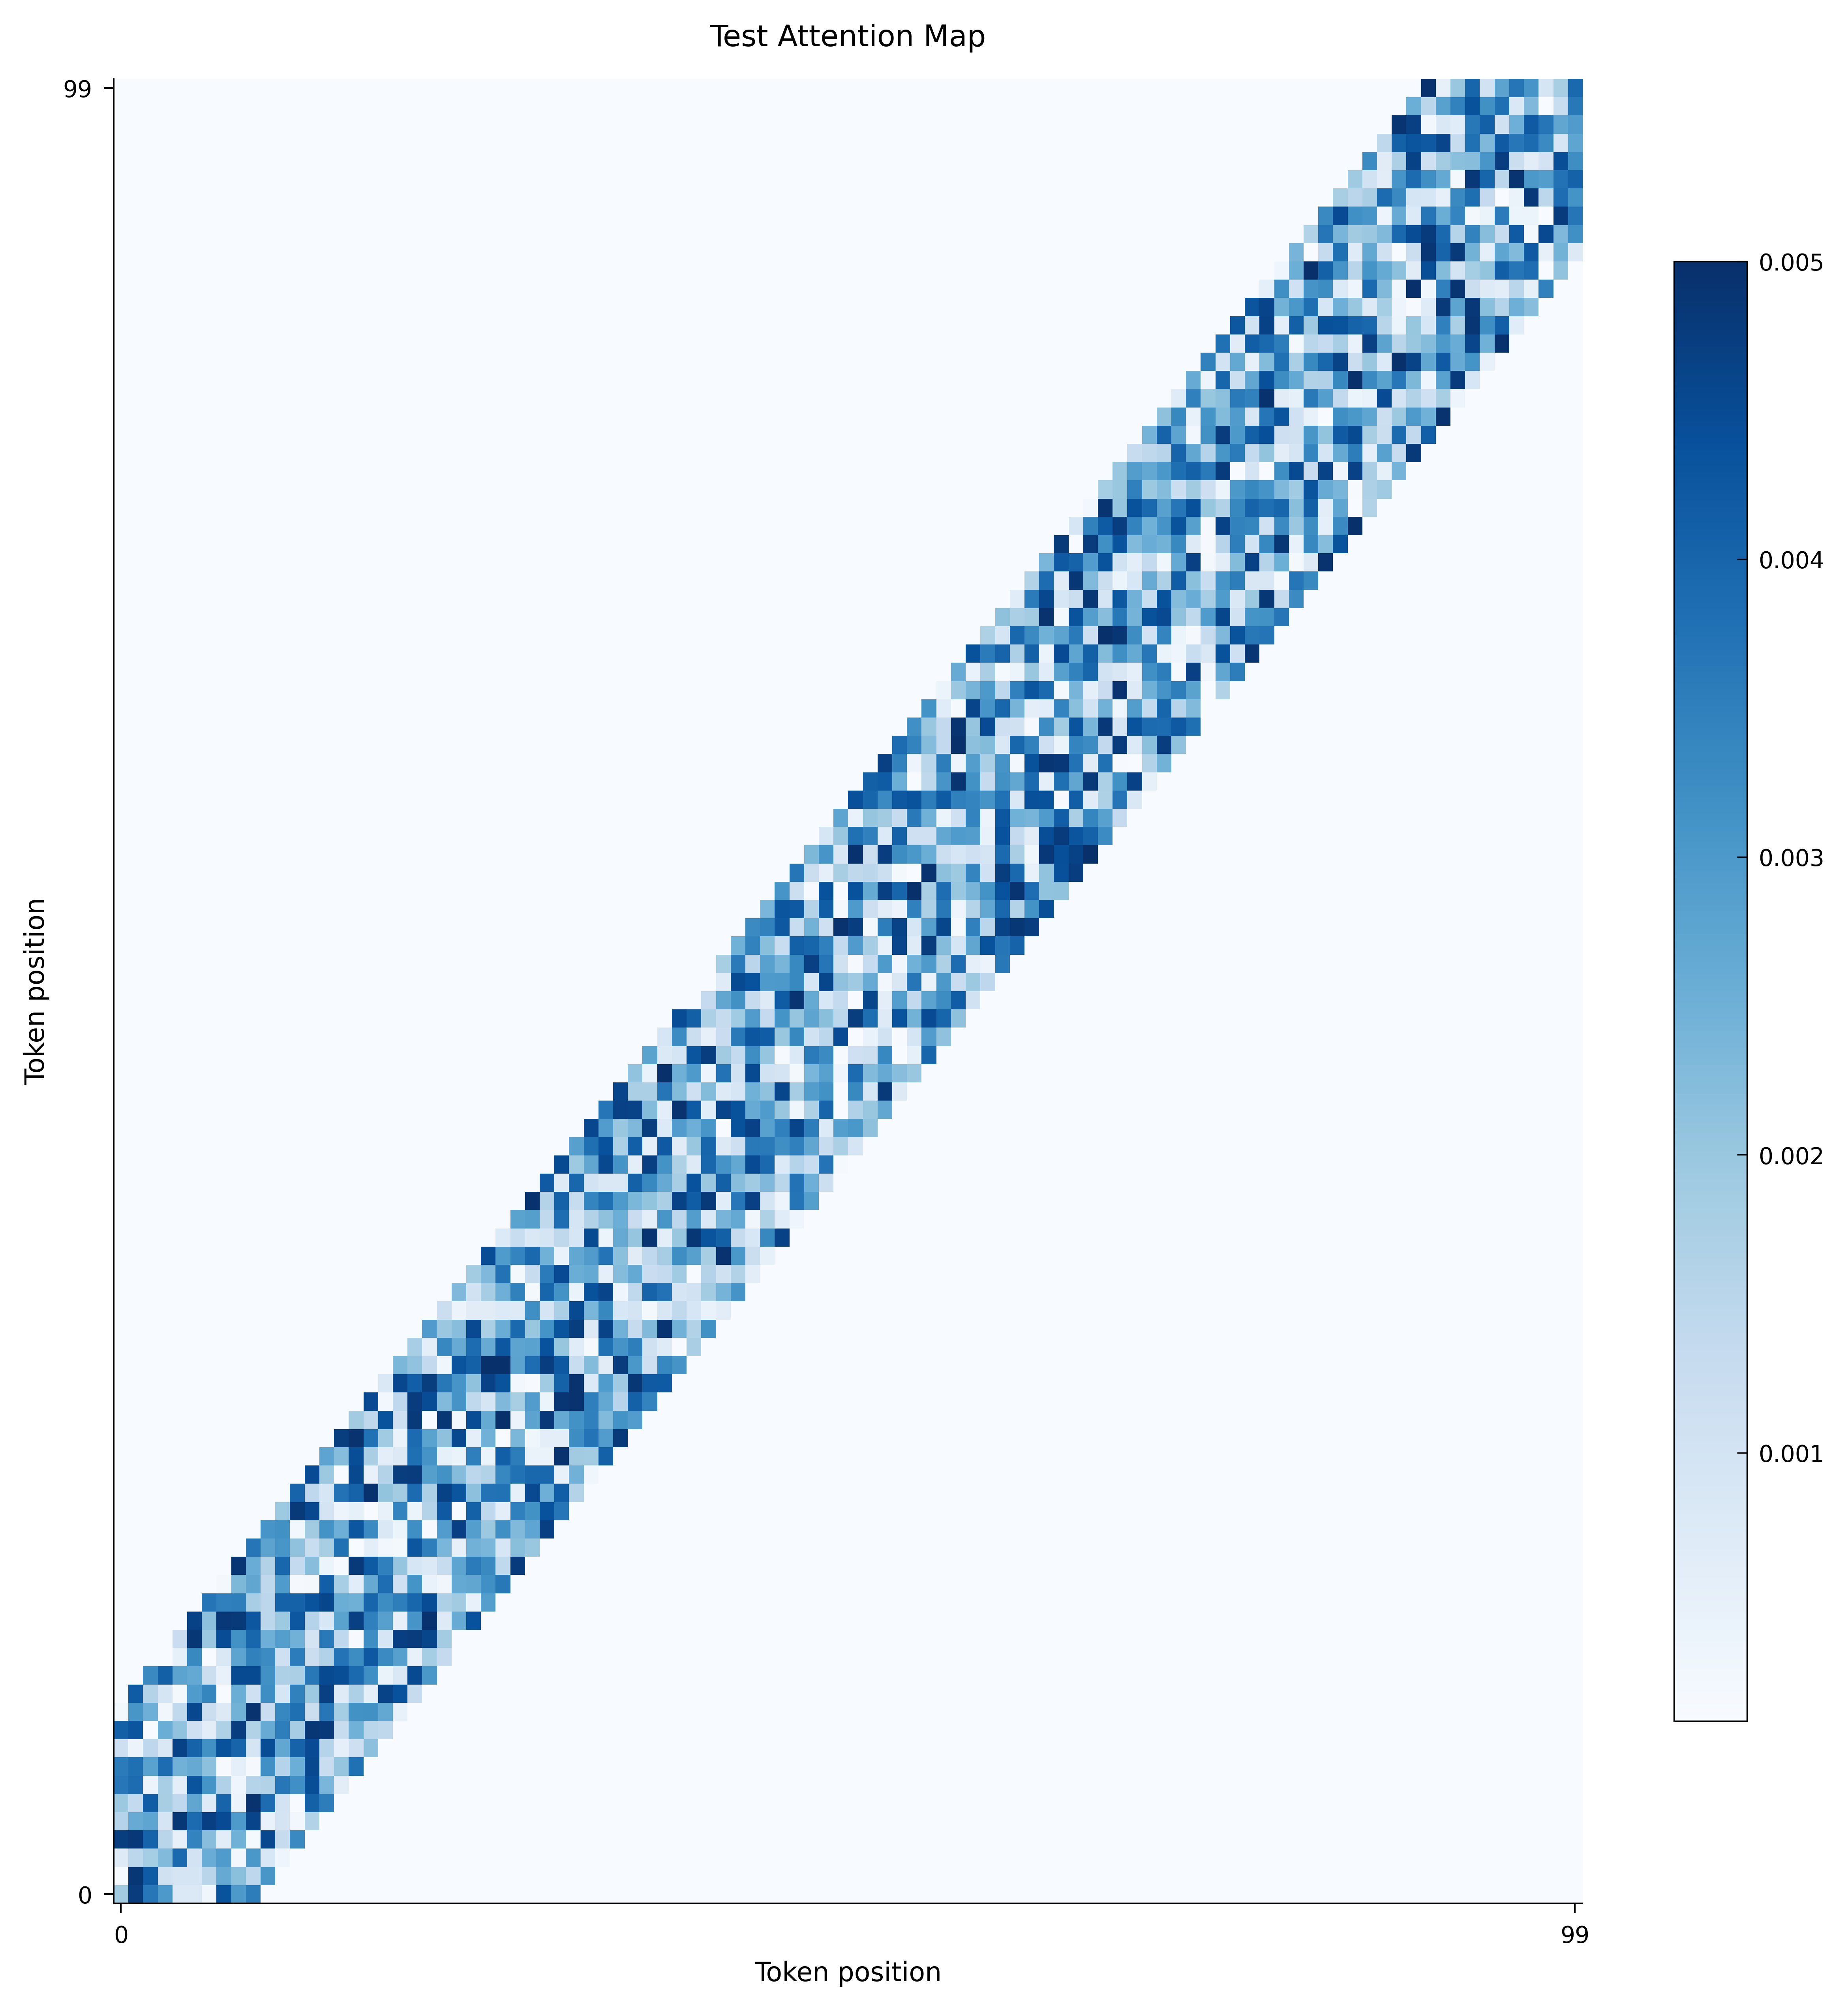

In [4]:
import pandas as pd
import numpy as np
LINE_WIDTH = 0.5
# 1. 创建测试用的注意力矩阵
seq_len = 100
attention_mat = np.zeros((seq_len, seq_len))
    
# 创建一些随机的注意力模式
np.random.seed(42)
for i in range(seq_len):
    # 每个位置对附近10个位置有较高的注意力
    start = max(0, i - 10)
    end = min(seq_len, i + 10)
    attention_mat[i, start:end] = np.random.rand(end - start) * 0.005

plot_attention_panel(
        attention_mat,
        cmap="Blues",
        vmin=0.0001,
        vmax=0.005,
        colorbar=True,
        figsize=(10, 10),
        variant_id="Test Attention Map",
        show_titles=True,
        show_xlabel=True,
        show_xticks=True,
        show_yticks=True,
        positions='TOKEN',
        token_resolution=128,
        show=True  # 不显示，只保存
    )